##  Session setup

In [1]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPO_URL = "https://github.com/Mudibo/AgriSence.git"
if IN_COLAB:
    REPO_DIR = Path("/content/AgriSence")
    if REPO_DIR.exists():
        !rm -rf {REPO_DIR}
    !git clone -b feature/data-cleaning {REPO_URL} {REPO_DIR}
    %cd {REPO_DIR / 'model'}
else:
    current_dir = Path.cwd().resolve()
    if current_dir.name == 'model':
        repo_model_dir = current_dir
    elif (current_dir / 'model').exists():
        repo_model_dir = current_dir / 'model'
    elif current_dir.parent.name == 'AgriSence' and (current_dir.parent / 'model').exists():
        repo_model_dir = current_dir.parent / 'model'
    else:
        raise FileNotFoundError('Start this notebook from the repository root or model directory.')
    %cd {repo_model_dir}

from config.constants import MARKETS, CROPS
from preprocessing.cleaning import (
    filter_target_scope, normalize_units, resolve_pricetype,
    resolve_label_overlap, build_monthly_calendar, quantify_missingness,
    diagnose_missing_gap_lengths, forward_fill_short_gaps,
    seasonal_interpolate_medium_gaps, list_missing_rows, flag_outliers_iqr,
)
from preprocessing.aggregation import aggregate_to_monthly

if Path('requirements.txt').exists():
    %pip install -r requirements.txt
else:
    raise FileNotFoundError('requirements.txt was not found in the current working directory.')

sns.set_theme(style='whitegrid')

Cloning into '/content/AgriSence'...
remote: Enumerating objects: 176, done.
remote: Counting objects: 100% (176/176), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 176 (delta 46), reused 155 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (176/176), 1.97 MiB | 7.18 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/AgriSence/model


### 1. Load raw dataset

In [2]:
WFP_URL = (
    'https://data.humdata.org/dataset/wfp-food-prices-for-kenya/resource/'
    '517ee1bf-2437-4f8c-aa1b-cb9925b9d437/download/wfp_food_prices_ken.csv'
)
raw_df = pd.read_csv(WFP_URL)
if raw_df.iloc[0].astype(str).str.match(r'^#').any():
    raw_df = raw_df.iloc[1:].reset_index(drop=True)
raw_df['market'] = raw_df['market'].str.strip().str.title()
raw_df['commodity'] = raw_df['commodity'].str.strip().str.title()
raw_df['date'] = pd.to_datetime(raw_df['date'])
print(raw_df.shape)

(27774, 16)


### 2. Filter to target markets and relabel commodities

In [3]:
RAW_COMMODITY_MAP = {'Maize (White)': 'Maize', 'Beans (Dry)': 'Beans'}
df = filter_target_scope(raw_df, MARKETS, RAW_COMMODITY_MAP)
print(df.shape)
df.groupby(['market', 'commodity']).size()

(3881, 16)


market   commodity              
Kisumu   Beans                      315
         Maize                      325
         Potatoes (Irish)           161
         Sorghum                    161
Mombasa  Beans                      310
         Maize                      300
         Potatoes (Irish)             3
         Sorghum                      3
Nairobi  Bananas                      1
         Beans                      315
         Bread                      178
         Cooking Fat                  1
         Fuel (Diesel)               67
         Fuel (Kerosene)             67
         Fuel (Petrol-Gasoline)      67
         Kale                         1
         Maize                      360
         Maize Flour                  1
         Meat (Beef)                  1
         Meat (Goat)                  1
         Milk (Cow, Pasteurized)    178
         Oil (Vegetable)            178
         Onions (Red)                 1
         Potatoes (Irish)           171
         Rice                         1
         Sorghum                    170
         Sugar                        1
         Tomatoes                     1
         Wheat Flour                  1
Nakuru   Beans                      191
         Maize                      226
         Potatoes (Irish)            62
         Sorghum                     62
dtype: int64

### 3. Normalize units to price per kg

In [4]:
df = normalize_units(df)
df[['commodity', 'unit', 'price', 'price_per_kg']].sample(min(10, len(df)), random_state=42)

Unhandled unit values; price_per_kg set to NaN: ['400 G', '50 KG', '500 ML', 'Bunch', 'L', 'Unit']


,commodity,unit,price,price_per_kg
5737,Fuel (Diesel),L,95.96,NaN
1639,Beans,90 KG,4741.25,52.680556
5455,Beans,KG,50.11,50.110000
6061,Bread,400 G,43.00,NaN
1928,Beans,KG,48.51,48.510000
2044,Maize,90 KG,3193.00,35.477778
1161,Beans,KG,69.42,69.420000
564,Beans,KG,36.76,36.760000
1960,Beans,KG,49.00,49.000000
514,Beans,KG,33.66,33.660000


### 4. Verify unit normalization closed the scale gap

In [5]:
comparison = df.groupby(['commodity'])['price_per_kg'].agg(['mean', 'std', 'min', 'max'])
print(comparison)


                               mean        std         min         max
commodity                                                             
Bananas                         NaN        NaN         NaN         NaN
Beans                     61.286817  15.703566   27.810000  113.244444
Bread                           NaN        NaN         NaN         NaN
Cooking Fat              104.000000        NaN  104.000000  104.000000
Fuel (Diesel)                   NaN        NaN         NaN         NaN
Fuel (Kerosene)                 NaN        NaN         NaN         NaN
Fuel (Petrol-Gasoline)          NaN        NaN         NaN         NaN
Kale                            NaN        NaN         NaN         NaN
Maize                     29.164443   9.168755   11.504667   60.020000
Maize Flour               62.000000        NaN   62.000000   62.000000
Meat (Beef)              431.000000        NaN  431.000000  431.000000
Meat (Goat)              533.170000        NaN  533.170000  533.170000
Milk (

### 5. Resolve pricetype to wholesale only

In [6]:
df = resolve_pricetype(df, preferred='Wholesale')
print(df.shape)

market   commodity                pricetype
Kisumu   Beans                    Wholesale    315
         Maize                    Wholesale    325
         Potatoes (Irish)         Wholesale    161
         Sorghum                  Wholesale    161
Mombasa  Beans                    Wholesale    310
         Maize                    Wholesale    300
         Potatoes (Irish)         Wholesale      3
         Sorghum                  Wholesale      3
Nairobi  Bananas                  Retail         1
         Beans                    Retail         1
                                  Wholesale    314
         Bread                    Retail       178
         Cooking Fat              Retail         1
         Fuel (Diesel)            Retail        67
         Fuel (Kerosene)          Retail        67
         Fuel (Petrol-Gasoline)   Retail        67
         Kale                     Retail         1
         Maize                    Retail         1
                                  Whol

### 6. Resolve any remaining label-overlap duplicates

In [7]:
df = resolve_label_overlap(df)
print(df.shape)
dupes = df[df.duplicated(subset=['market', 'commodity', 'date'], keep=False)]
print(f'Remaining duplicates: {len(dupes)}')

Overlapping (market, commodity, date) rows averaged: 1972
(2145, 17)
Remaining duplicates: 0


### 7. Build the full monthly calendar and quantify missingness

In [8]:
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()
calendar = build_monthly_calendar(MARKETS, CROPS, df['month'].min(), df['month'].max())
missingness_summary = quantify_missingness(df, calendar)
missingness_summary

Overall missingness: 13.65%


,market,commodity,missing_months,expected_months,missing_proportion
0,Kisumu,Beans,32,196,0.163265
1,Kisumu,Maize,28,196,0.142857
2,Mombasa,Beans,28,196,0.142857
3,Mombasa,Maize,18,196,0.091837
4,Nairobi,Beans,17,196,0.086735
5,Nairobi,Maize,6,196,0.030612
6,Nakuru,Beans,53,196,0.270408
7,Nakuru,Maize,32,196,0.163265


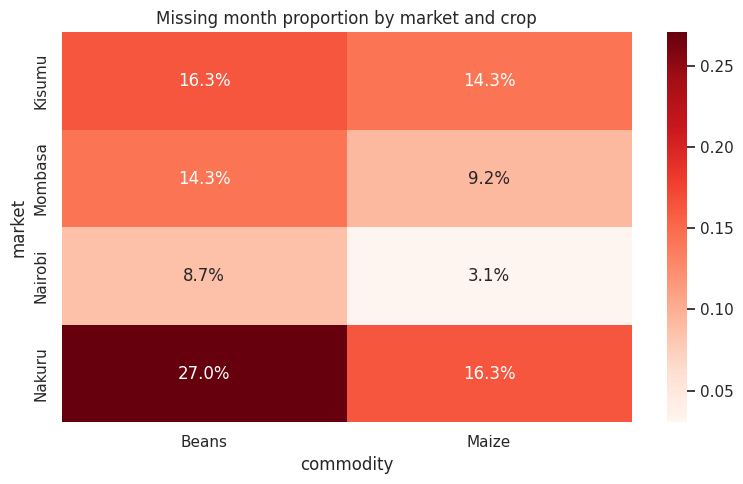

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(missingness_summary.pivot(index='market', columns='commodity', values='missing_proportion'), annot=True, fmt='.1%', cmap='Reds')
plt.title('Missing month proportion by market and crop')
plt.tight_layout()
plt.show()

### 8. Aggregate to monthly frequency

In [10]:
monthly_df = aggregate_to_monthly(df)
monthly_df.tail()

,market,commodity,month,avg_price_per_kg
2140,Nakuru,Sorghum,2019-11-01,38.888889
2141,Nakuru,Sorghum,2019-12-01,38.888889
2142,Nakuru,Sorghum,2020-01-01,39.513889
2143,Nakuru,Sorghum,2020-02-01,36.666667
2144,Nakuru,Sorghum,2020-03-01,30.000000


### 9. Reindex against the full calendar to expose gaps explicitly

In [11]:
full_panel = calendar.merge(monthly_df, on=['market', 'commodity', 'month'], how='left')
print(f'Total expected rows: {len(calendar)}')
print(f'Rows with an observed price: {full_panel["avg_price_per_kg"].notna().sum()}')

Total expected rows: 1568
Rows with an observed price: 1354


### 10. Diagnose missing-month gap lengths

In [12]:
gap_runs = diagnose_missing_gap_lengths(full_panel, value_col='avg_price_per_kg')
print(gap_runs['gap_length_months'].describe())
gap_runs.groupby('gap_length_months').size().sort_index()

count    36.000000
mean      5.944444
std       8.420874
min       1.000000
25%       1.000000
50%       2.000000
75%       5.750000
max      30.000000
Name: gap_length_months, dtype: float64


,0
gap_length_months,
1,15
2,8
3,1
4,1
5,2
8,1
9,2
14,1
22,1


### 11. Tiered gap handling: short (forward-fill), medium (seasonal), long (leave missing)

<p>Short gaps (2 months or fewer) are forward-filled. Medium gaps (3-6 months) are filled using the same calendar month's price one year earlier/later (or linear interpolation if no seasonal reference exists), since a seasonal reference is safer than extrapolating a multi-month trend. Gaps longer than 6 months are left as missing rather than fabricated, since imputing over that many months risks inventing a trend the model would then treat as real.</p>

In [13]:
full_panel = forward_fill_short_gaps(full_panel, value_col='avg_price_per_kg', max_gap_months=2)
full_panel = seasonal_interpolate_medium_gaps(full_panel, value_col='avg_price_per_kg', min_gap_months=3, max_gap_months=6)

full_panel['impute_method'] = 'observed'
full_panel.loc[full_panel['was_imputed'], 'impute_method'] = 'short_gap_ffill'
full_panel.loc[full_panel['was_interpolated'], 'impute_method'] = 'medium_gap_seasonal'
full_panel.loc[full_panel['avg_price_per_kg'].isna(), 'impute_method'] = 'long_gap_unfilled'

print(full_panel['impute_method'].value_counts())
print(f'Remaining missing after tiered fill: {full_panel["avg_price_per_kg"].isna().sum()}')

impute_method
observed               1354
long_gap_unfilled       166
short_gap_ffill          31
medium_gap_seasonal      17
Name: count, dtype: int64
Remaining missing after tiered fill: 166


### 12. Verify gap handling: what was filled and what remains

In [14]:
fill_counts = full_panel['impute_method'].value_counts().rename('rows')
fill_share = (fill_counts / len(full_panel)).rename('share')
print(pd.concat([fill_counts, fill_share.map('{:.2%}'.format)], axis=1), '\n')

print(f'Calendar months expected : {len(calendar)}')
print(f'Panel rows present       : {len(full_panel)}')
print(f'Absent calendar rows     : {len(calendar) - len(full_panel)}')
print(f'Null prices remaining    : {int(full_panel["avg_price_per_kg"].isna().sum())}\n')

# quantify_missingness treats a row as observed only if it carries a price.
post_fill_missingness = quantify_missingness(
    full_panel[full_panel['avg_price_per_kg'].notna()], calendar
)

fill_audit = missingness_summary.merge(
    post_fill_missingness, on=['market', 'commodity'], suffixes=('_before', '_after')
)
fill_audit['months_recovered'] = (
    fill_audit['missing_months_before'] - fill_audit['missing_months_after']
)
fill_audit[[
    'market', 'commodity', 'missing_months_before', 'months_recovered',
    'missing_months_after', 'missing_proportion_after',
]]

                     rows   share
impute_method                    
observed             1354  86.35%
long_gap_unfilled     166  10.59%
short_gap_ffill        31   1.98%
medium_gap_seasonal    17   1.08% 

Calendar months expected : 1568
Panel rows present       : 1568
Absent calendar rows     : 0
Null prices remaining    : 166

Overall missingness: 10.59%


,market,commodity,missing_months_before,months_recovered,missing_months_after,missing_proportion_after
0,Kisumu,Beans,32,2,30,0.153061
1,Kisumu,Maize,28,6,22,0.112245
2,Mombasa,Beans,28,3,25,0.127551
3,Mombasa,Maize,18,9,9,0.045918
4,Nairobi,Beans,17,9,8,0.040816
5,Nairobi,Maize,6,6,0,0.000000
6,Nakuru,Beans,53,6,47,0.239796
7,Nakuru,Maize,32,7,25,0.127551


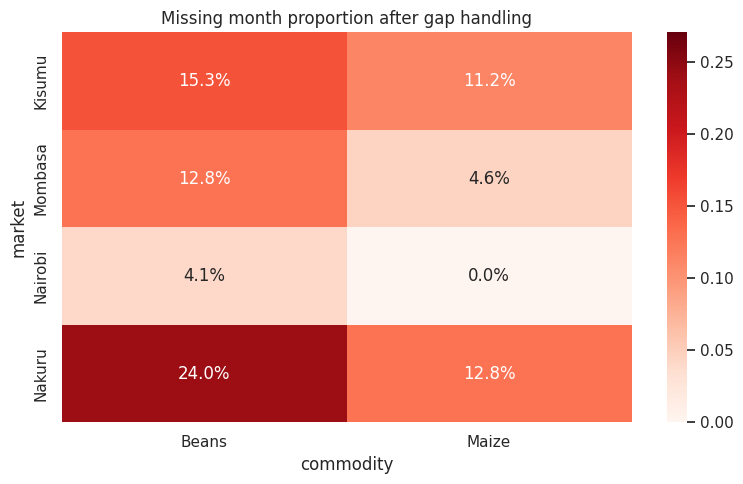

In [15]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    post_fill_missingness.pivot(index='market', columns='commodity', values='missing_proportion'),
    annot=True,
    fmt='.1%',
    cmap='Reds',
    vmin=0,
    vmax=missingness_summary['missing_proportion'].max(),  # shared scale with the pre-fill heatmap
)
plt.title('Missing month proportion after gap handling')
plt.tight_layout()
plt.show()

In [16]:
absent_rows = len(calendar) - len(full_panel)
unfilled = full_panel[full_panel['avg_price_per_kg'].isna()]

print(f'Every market-crop-month present in panel: {absent_rows == 0}')
print(f'Months still without a price           : {len(unfilled)}')

if len(unfilled):
    print('\nRemaining gaps are the >6-month runs left unfilled by design:')
    display(
        unfilled.groupby(['market', 'commodity'])['month']
        .agg(first_missing='min', last_missing='max', months='count')
    )
else:
    print('\nNo missing months or prices remain.')

Every market-crop-month present in panel: True
Months still without a price           : 166

Remaining gaps are the >6-month runs left unfilled by design:


first_missing last_missing  months
market  commodity                                   
Kisumu  Beans        2019-11-01   2022-04-01      30
        Maize        2020-04-01   2022-01-01      22
Mombasa Beans        2020-04-01   2022-04-01      25
        Maize        2020-04-01   2020-12-01       9
Nairobi Beans        2020-05-01   2020-12-01       8
Nakuru  Beans        2006-01-01   2022-04-01      47
        Maize        2006-01-01   2008-01-01      25

In [15]:
missing_rows = list_missing_rows(full_panel, value_col='avg_price_per_kg')

# Leading/trailing runs are coverage limits to truncate; interior runs are true reporting gaps.
print(missing_rows['gap_position'].value_counts(), '\n')
print(
    missing_rows.groupby(['market', 'commodity', 'gap_position'])['month']
    .agg(first_missing='min', last_missing='max', months='count')
)

missing_rows[['market', 'commodity', 'month', 'gap_position', 'gap_length_months', 'month_in_gap']]

gap_position
trailing    69
leading     49
interior    48
Name: count, dtype: int64 

                               first_missing last_missing  months
market  commodity gap_position                                   
Kisumu  Beans     trailing        2019-11-01   2022-04-01      30
        Maize     interior        2020-04-01   2022-01-01      22
Mombasa Beans     trailing        2020-04-01   2022-04-01      25
        Maize     interior        2020-04-01   2020-12-01       9
Nairobi Beans     interior        2020-05-01   2020-12-01       8
Nakuru  Beans     interior        2020-04-01   2020-12-01       9
                  leading         2006-01-01   2007-12-01      24
                  trailing        2021-03-01   2022-04-01      14
        Maize     leading         2006-01-01   2008-01-01      25


,market,commodity,month,gap_position,gap_length_months,month_in_gap
0,Kisumu,Beans,2019-11-01,trailing,30,1
1,Kisumu,Beans,2019-12-01,trailing,30,2
2,Kisumu,Beans,2020-01-01,trailing,30,3
3,Kisumu,Beans,2020-02-01,trailing,30,4
4,Kisumu,Beans,2020-03-01,trailing,30,5
...,...,...,...,...,...,...
161,Nakuru,Maize,2007-09-01,leading,25,21
162,Nakuru,Maize,2007-10-01,leading,25,22
163,Nakuru,Maize,2007-11-01,leading,25,23
164,Nakuru,Maize,2007-12-01,leading,25,24


In [21]:
missing_rows_since_2014 = missing_rows[missing_rows['month'] >= '2014-01-01']

print(f'Missing rows from 2014 onward: {len(missing_rows_since_2014)}')
print(missing_rows_since_2014['gap_position'].value_counts())

missing_rows_since_2014[['market', 'commodity', 'month', 'gap_position', 'gap_length_months', 'month_in_gap']]

Missing rows from 2014 onward: 117
gap_position
trailing    69
interior    48
Name: count, dtype: int64


,market,commodity,month,gap_position,gap_length_months,month_in_gap
0,Kisumu,Beans,2019-11-01,trailing,30,1
1,Kisumu,Beans,2019-12-01,trailing,30,2
2,Kisumu,Beans,2020-01-01,trailing,30,3
3,Kisumu,Beans,2020-02-01,trailing,30,4
4,Kisumu,Beans,2020-03-01,trailing,30,5
...,...,...,...,...,...,...
136,Nakuru,Beans,2021-12-01,trailing,14,10
137,Nakuru,Beans,2022-01-01,trailing,14,11
138,Nakuru,Beans,2022-02-01,trailing,14,12
139,Nakuru,Beans,2022-03-01,trailing,14,13


### 13. Flag outliers 

In [16]:
full_panel = flag_outliers_iqr(full_panel, value_col='avg_price_per_kg')
print(f'Flagged outliers: {full_panel["is_outlier"].sum()}')
full_panel[full_panel['is_outlier']]

Flagged outliers: 38


,market,commodity,month,avg_price_per_kg,was_imputed,was_interpolated,impute_method,is_outlier
331,Kisumu,Maize,2017-04-01,55.308333,False,False,observed,True
332,Kisumu,Maize,2017-05-01,58.583889,False,False,observed,True
333,Kisumu,Maize,2017-06-01,57.121111,False,False,observed,True
527,Mombasa,Beans,2017-04-01,98.080556,False,False,observed,True
528,Mombasa,Beans,2017-05-01,98.445000,False,False,observed,True
561,Mombasa,Beans,2020-02-01,97.222222,False,False,observed,True
562,Mombasa,Beans,2020-03-01,100.000000,False,False,observed,True
724,Mombasa,Maize,2017-05-01,55.056111,False,False,observed,True
725,Mombasa,Maize,2017-06-01,52.622778,False,False,observed,True
790,Nairobi,Beans,2006-07-01,30.483333,False,False,observed,True


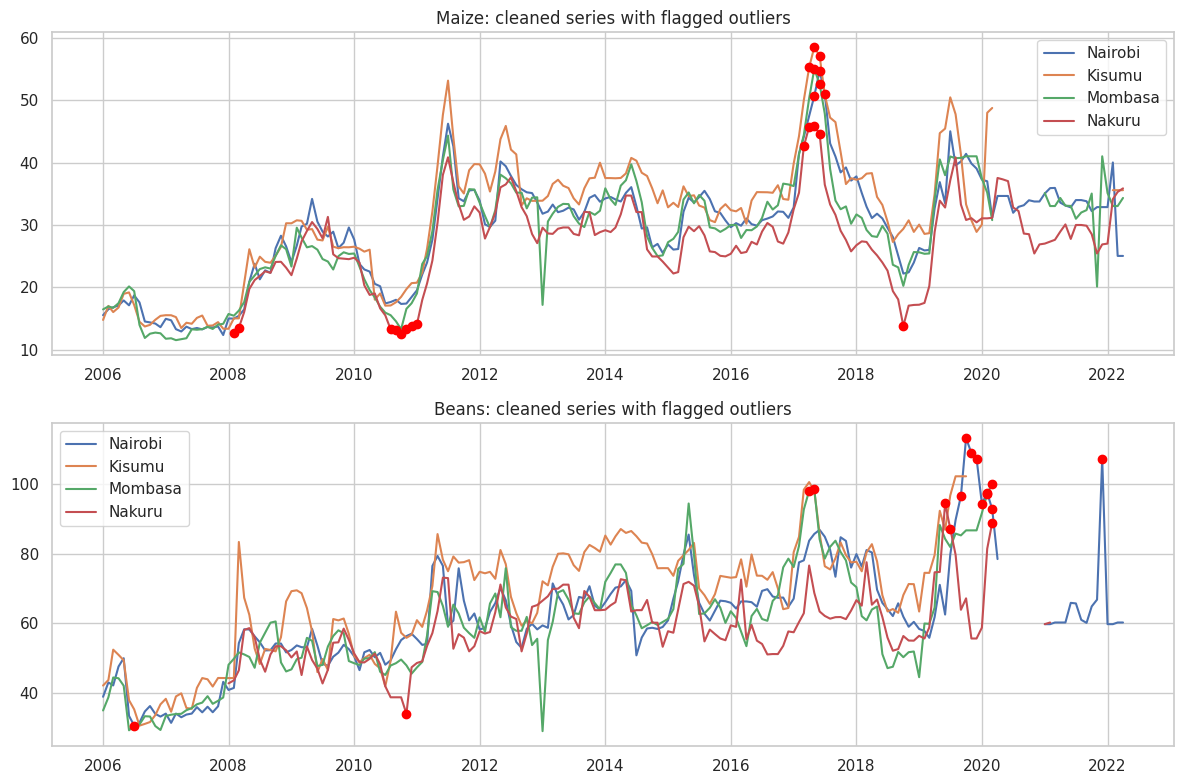

In [19]:
fig, axes = plt.subplots(len(CROPS), 1, figsize=(12, 4 * len(CROPS)))
for ax, crop in zip(axes, CROPS):
    subset = full_panel[full_panel['commodity'] == crop]
    for market in MARKETS:
        market_subset = subset[subset['market'] == market]
        ax.plot(market_subset['month'], market_subset['avg_price_per_kg'], label=market)
        outliers = market_subset[market_subset['is_outlier']]
        ax.scatter(outliers['month'], outliers['avg_price_per_kg'], color='red', zorder=5)
    ax.set_title(f'{crop}: cleaned series with flagged outliers')
    ax.legend()
plt.tight_layout()
plt.show()

### 14. Apply per-series analysis windows

Each market-crop series keeps its own first and last observed month. Leading and trailing coverage gaps are excluded without sacrificing recent data from other series. Remaining internal gaps stay explicit and are excluded from target-based training rows.

In [17]:
observed_panel = full_panel[full_panel['avg_price_per_kg'].notna()].copy()
coverage_check = (
    observed_panel.groupby(['market', 'commodity'])['month']
    .agg(
        first_observed_month='min',
        last_observed_month='max',
        observed_months='count',
    )
    .reset_index()
)
coverage_check

,market,commodity,first_observed_month,last_observed_month,observed_months
0,Kisumu,Beans,2006-01-01,2019-10-01,166
1,Kisumu,Maize,2006-01-01,2022-04-01,174
2,Mombasa,Beans,2006-01-01,2020-03-01,171
3,Mombasa,Maize,2006-01-01,2022-04-01,187
4,Nairobi,Beans,2006-01-01,2022-04-01,188
5,Nairobi,Maize,2006-01-01,2022-04-01,196
6,Nakuru,Beans,2008-01-01,2021-02-01,149
7,Nakuru,Maize,2008-02-01,2022-04-01,171


In [ ]:
final_df = full_panel.merge(
    coverage_check,
    on=['market', 'commodity'],
    how='inner',
)
final_df = final_df[
    (final_df['month'] >= final_df['first_observed_month'])
    & (final_df['month'] <= final_df['last_observed_month'])
].copy()

final_missing = final_df[final_df['avg_price_per_kg'].isna()]
print(f'Per-series panel rows: {len(final_df)}')
print(f'Rows with a price: {final_df["avg_price_per_kg"].notna().sum()}')
print(f'Internal missing target rows: {len(final_missing)}')
print(f'Series retained: {coverage_check.shape[0]}')

final_df.groupby(['market', 'commodity']).agg(
    window_start=('month', 'min'),
    window_end=('month', 'max'),
    rows=('month', 'size'),
    missing_targets=('avg_price_per_kg', lambda values: values.isna().sum()),
)

Per-series panel rows: 1450
Rows with a price: 1402
Internal missing target rows: 48
Series retained: 8


window_start window_end  rows  missing_targets
market  commodity                                               
Kisumu  Beans       2006-01-01 2019-10-01   166                0
        Maize       2006-01-01 2022-04-01   196               22
Mombasa Beans       2006-01-01 2020-03-01   171                0
        Maize       2006-01-01 2022-04-01   196                9
Nairobi Beans       2006-01-01 2022-04-01   196                8
        Maize       2006-01-01 2022-04-01   196                0
Nakuru  Beans       2008-01-01 2021-02-01   158                9
        Maize       2008-02-01 2022-04-01   171                0

In [24]:
missing_target_rows = final_df[final_df['avg_price_per_kg'].isna()].copy()

print(f'Missing target rows: {len(missing_target_rows)}')
print('\nMissing targets by market and commodity:')
print(missing_target_rows.groupby(['market', 'commodity']).size().rename('missing_rows'))

print('\nMissing target dates by series:')
missing_target_summary = (
    missing_target_rows.groupby(['market', 'commodity'])['month']
    .agg(first_missing='min', last_missing='max', missing_months='count')
    .reset_index()
)
display(missing_target_summary)

print('\nExact missing-target rows:')
missing_target_rows[
    [
        'market',
        'commodity',
        'month',
        'avg_price_per_kg',
        'impute_method',
        'is_outlier',
    ]
]

Missing target rows: 48

Missing targets by market and commodity:
market   commodity
Kisumu   Maize        22
Mombasa  Maize         9
Nairobi  Beans         8
Nakuru   Beans         9
Name: missing_rows, dtype: int64

Missing target dates by series:


,market,commodity,first_missing,last_missing,missing_months
0,Kisumu,Maize,2020-04-01,2022-01-01,22
1,Mombasa,Maize,2020-04-01,2020-12-01,9
2,Nairobi,Beans,2020-05-01,2020-12-01,8
3,Nakuru,Beans,2020-04-01,2020-12-01,9



Exact missing-target rows:


,market,commodity,month,avg_price_per_kg,impute_method,is_outlier
367,Kisumu,Maize,2020-04-01,NaN,long_gap_unfilled,False
368,Kisumu,Maize,2020-05-01,NaN,long_gap_unfilled,False
369,Kisumu,Maize,2020-06-01,NaN,long_gap_unfilled,False
370,Kisumu,Maize,2020-07-01,NaN,long_gap_unfilled,False
371,Kisumu,Maize,2020-08-01,NaN,long_gap_unfilled,False
372,Kisumu,Maize,2020-09-01,NaN,long_gap_unfilled,False
373,Kisumu,Maize,2020-10-01,NaN,long_gap_unfilled,False
374,Kisumu,Maize,2020-11-01,NaN,long_gap_unfilled,False
375,Kisumu,Maize,2020-12-01,NaN,long_gap_unfilled,False
376,Kisumu,Maize,2021-01-01,NaN,long_gap_unfilled,False


### 15. Save cleaned dataset

In [ ]:
Path('artifacts').mkdir(exist_ok=True)
if IN_COLAB:
    Path('/content/drive/MyDrive/capstone-data').mkdir(parents=True, exist_ok=True)
    final_df.to_csv('/content/drive/MyDrive/capstone-data/cleaned_monthly_prices.csv', index=False)
final_df.to_csv('artifacts/training_data_snapshot.csv', index=False)